# Plots and results

In [14]:
import os
import sys
from dotenv import load_dotenv
load_dotenv()

root_dir = os.getenv('PROJECT_ROOT')
tokenizer_models_dir = os.getenv('TOK_DIR')
root_coco = os.getenv('DATA_DIR')
train_coco = os.getenv('TRAIN_DIR')
val_coco = os.getenv('VAL_DIR')

src_dir = os.path.join(root_dir, "src")
train_folder = os.path.join(root_coco, f"{train_coco}")
val_folder = os.path.join(root_coco, f"{val_coco}")
train_ann_file = os.path.join(root_coco, "annotations", f"captions_{train_coco}.json")
val_ann_file = os.path.join(root_coco, "annotations", f"captions_{val_coco}.json")


if src_dir not in sys.path:
    sys.path.insert(0, src_dir)
os.chdir(src_dir)

True

In [15]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

def plot_trainer_logs(log_file):
    """
    Load and visualize training logs saved by ImageCaptioningTrainer.

    Parameters:
    -----------
    log_file : str or Path
        Path to 'logs.json' file saved during training.
    """
    log_path = Path(log_file)
    if not log_path.exists():
        raise FileNotFoundError(f"❌ Log file not found: {log_file}")

    with open(log_path, 'r') as f:
        logs = json.load(f)

    # Extract all available keys
    available_keys = list(logs.keys())
    print(f"📊 Available log keys: {available_keys}")

    def safe_plot(x_key, y_key, title, ylabel, log_scale=False):
        """Helper to safely plot only if both keys exist and have data."""
        if x_key in logs and y_key in logs and len(logs[x_key]) and len(logs[y_key]):
            plt.figure(figsize=(10, 6))
            plt.plot(logs[x_key], logs[y_key], label=y_key, linewidth=2)
            plt.title(title)
            plt.xlabel(x_key.replace('_', ' ').title())
            plt.ylabel(ylabel)
            if log_scale:
                plt.yscale('log')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
        else:
            print(f"⚠️ Skipping {y_key} — missing or empty data.")

    # Plot training loss and moving average
    safe_plot("steps_train", "train_loss", "Training Loss", "Loss")
    safe_plot("steps_train", "train_loss_ma", "Training Loss (Moving Average)", "Loss (MA)")

    # Plot validation loss
    safe_plot("steps_val", "val_loss", "Validation Loss", "Val Loss")

    # Plot BLEU and ROUGE-L if available
    safe_plot("steps_val", "val_bleu", "Validation BLEU Score", "BLEU")
    safe_plot("steps_val", "val_rouge_l", "Validation ROUGE-L Score", "ROUGE-L")

    # Plot learning rate
    safe_plot("steps_train", "lr", "Learning Rate Schedule", "Learning Rate", log_scale=True)

    # Plot gradient norm if available
    safe_plot("steps_train", "grad_norm", "Gradient Norm", "Grad Norm")

    # Plot tokens per second
    safe_plot("steps_train", "tok_per_sec", "Throughput", "Tokens per second")

    # Plot step time
    safe_plot("steps_train", "step_time", "Step Time", "Seconds per Step")

    print("✅ All available plots displayed.")


📊 Available log keys: ['train_loss', 'train_loss_ma', 'val_loss', 'val_bleu', 'val_rouge_l', 'val_cider', 'steps_train', 'steps_val', 'lr', 'tok_per_sec', 'grad_norm', 'epochs', 'step_time']


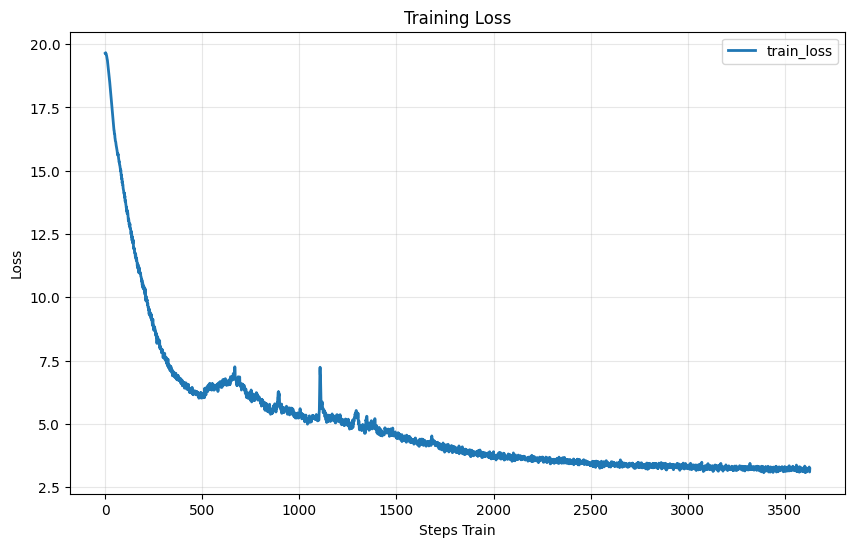

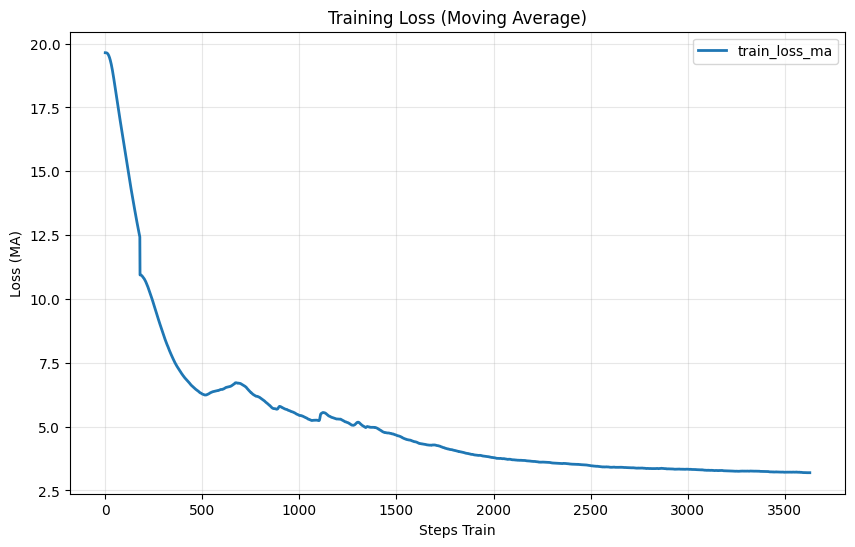

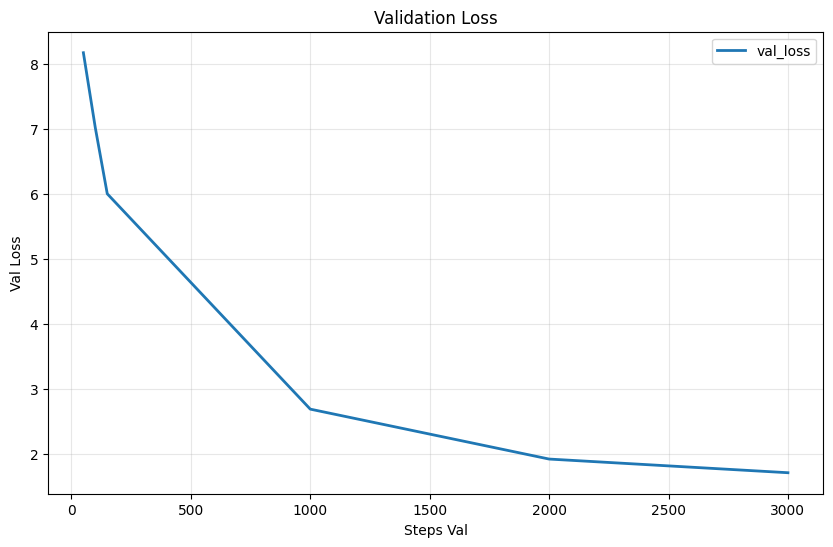

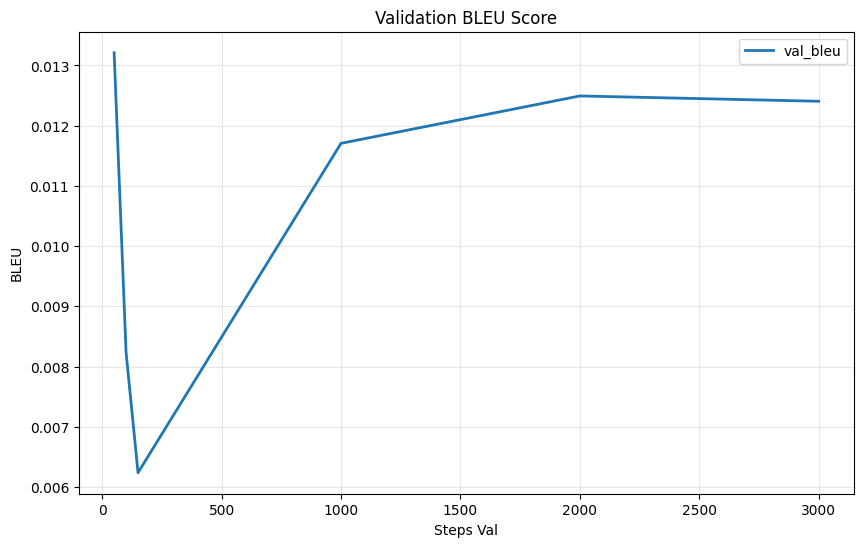

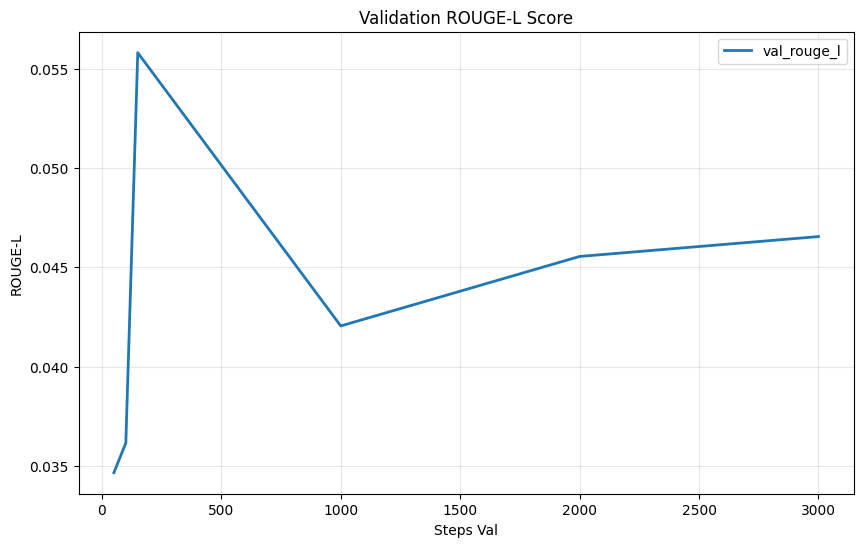

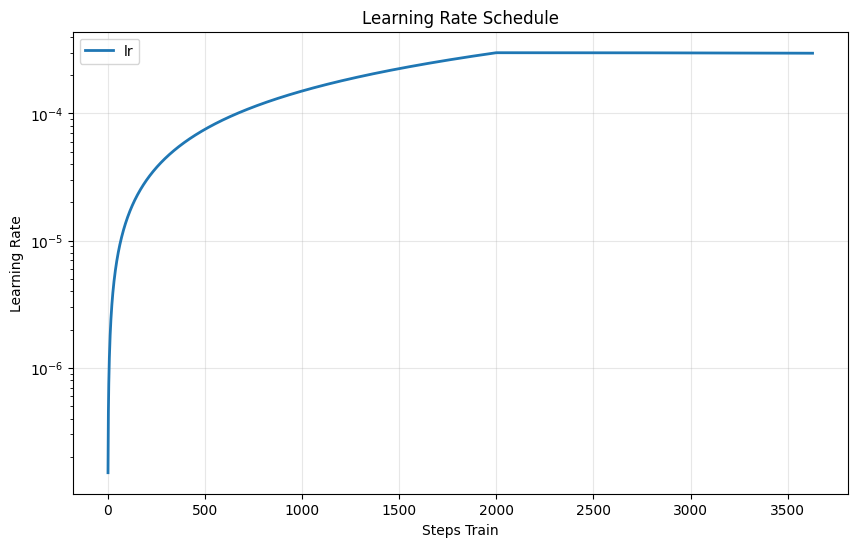

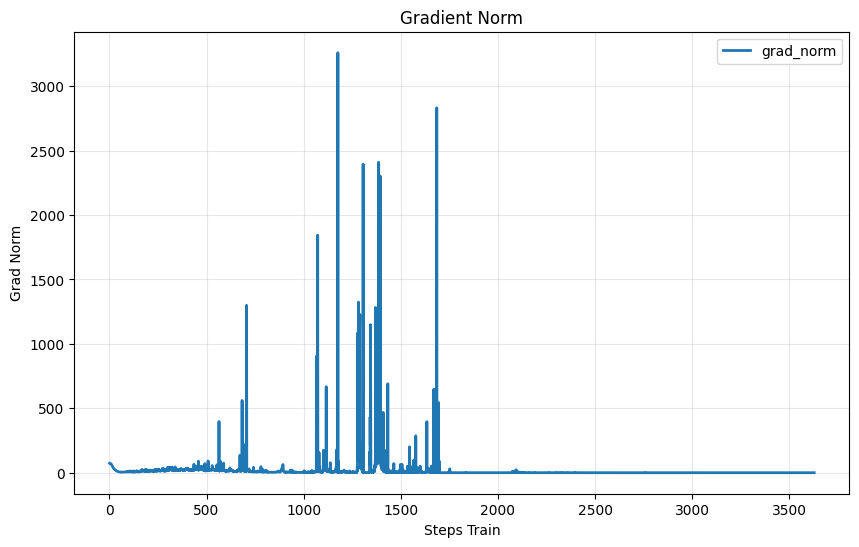

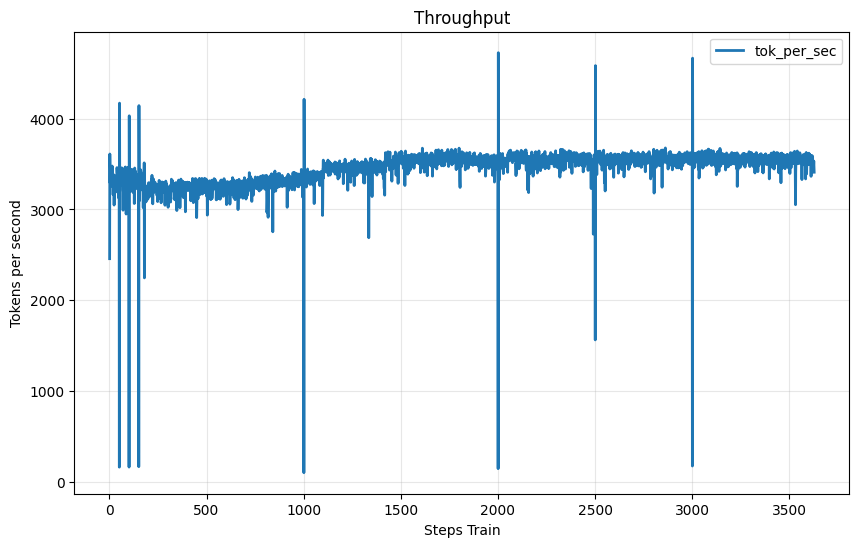

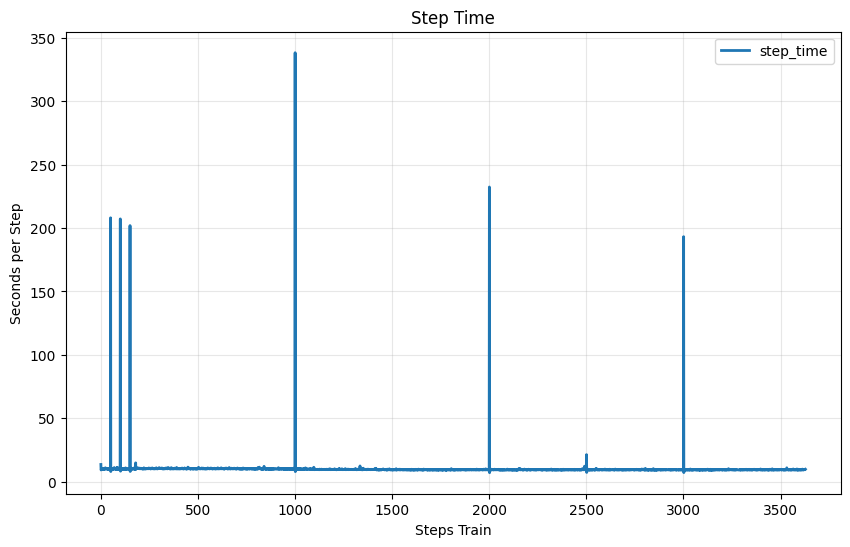

✅ All available plots displayed.


In [16]:
plot_trainer_logs("/home/mahanthyalla/dev/image-captioning-ViT-GPT/src/checkpoints/vitgpt-base/vit-gpt-base/v7.8.ddp_train/training/interrupt/interrupt_step_3628/logs.json")

In [17]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from pathlib import Path
import json

from model.vit_based_img_cap_model import ViTImageCaptioningModel
from training.trainer import CaptioningTrainerConfig
from training.utils import load_config_from_yaml
import constants as cnst

@torch.no_grad()
def visualize_caption_samples(
    checkpoint_dir,
    tokenizer,
    val_loader=None,
    device="cuda" if torch.cuda.is_available() else "cpu",
    num_samples=4,
    max_caption_length=35,
    temperature=0.8,
    top_k=50,
    top_p=0.9
):
    """
    Load a trained image captioning model from checkpoint and visualize generated captions.
    """
    checkpoint_dir = Path(checkpoint_dir)
    model_path = checkpoint_dir / "model.pt"
    config_path = checkpoint_dir / "model_config.pt"

    if not model_path.exists():
        raise FileNotFoundError(f"❌ Model file not found at: {model_path}")
    if not config_path.exists():
        raise FileNotFoundError(f"❌ Model config not found at: {config_path}")

    print(f"📦 Loading model from {model_path}")
    model_kwargs = torch.load(config_path, map_location=device)

    # Instantiate model
    model = ViTImageCaptioningModel(**model_kwargs)

    # --- Load state dict safely (handles DDP checkpoints) ---
    state_dict = torch.load(model_path, map_location=device)
    if any(k.startswith("module.") for k in state_dict.keys()):
        print("🧩 Detected DDP checkpoint — removing 'module.' prefixes...")
        state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    if missing:
        print(f"⚠️ Missing keys ({len(missing)}): {missing[:5]}{'...' if len(missing) > 5 else ''}")
    if unexpected:
        print(f"⚠️ Unexpected keys ({len(unexpected)}): {unexpected[:5]}{'...' if len(unexpected) > 5 else ''}")

    model.to(device)
    model.eval()
    print(f"✅ Model loaded successfully on {device}")

    # --- Load sample batch ---
    if val_loader is None:
        raise ValueError("val_loader must be provided to visualize samples")

    images, captions = next(iter(val_loader))
    num_samples = min(num_samples, images.shape[0])
    images = images[:num_samples].to(device)
    captions = captions[:num_samples]

    # --- Generate captions ---
    print("🧠 Generating captions...")
    generated = model.generate_caption(
        images=images,
        tokenizer=tokenizer,
        max_length=max_caption_length,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p
    )

    # --- Visualization ---
    mean = torch.tensor([0.471, 0.448, 0.408]).view(3, 1, 1).to(device)
    std = torch.tensor([0.234, 0.239, 0.242]).view(3, 1, 1).to(device)

    plt.figure(figsize=(12, 3 * num_samples))
    for i in range(num_samples):
        img_tensor = images[i].cpu() * std.cpu() + mean.cpu()
        img_tensor = torch.clamp(img_tensor, 0, 1)
        img_pil = Image.fromarray((img_tensor.permute(1, 2, 0) * 255).numpy().astype(np.uint8))

        gen_tokens = generated[i].cpu().tolist()
        pred_caption = tokenizer.decode([t for t in gen_tokens if t not in [
            tokenizer.special_tokens.get(cnst.TOKEN_SOS, 0),
            tokenizer.special_tokens.get(cnst.TOKEN_EOS, 1),
            tokenizer.special_tokens.get(cnst.TOKEN_PAD, -100)
        ]])

        ref_tokens = captions[i].tolist()
        ref_tokens = [t for t in ref_tokens if t not in [
            tokenizer.special_tokens.get(cnst.TOKEN_SOS, 0),
            tokenizer.special_tokens.get(cnst.TOKEN_EOS, 1),
            tokenizer.special_tokens.get(cnst.TOKEN_PAD, -100)
            ]]
        ref_caption = tokenizer.decode(ref_tokens)

        plt.subplot(num_samples, 1, i + 1)
        plt.imshow(img_pil)
        plt.axis("off")
        plt.title(
            f"Generated: {pred_caption}\nReference: {ref_caption}",
            fontsize=10,
            wrap=True
        )
        print(f"🟢 Generated: {pred_caption}\n🔵 Reference: {ref_caption}")

    plt.tight_layout()
    plt.show()

In [22]:
import utils as main_ut

decoder_vocab_size = 16384

tokenizer = main_ut.get_tokenizer(
    decoder_vocab_size,
    model = 'caps_bpe',
    )

val_loader = main_ut.get_coco_dataloader(
    tokenizer=tokenizer,
    batch_size=8,
    max_seq_len=64 + 1,
    resize_to=512,
    datatype='val'
    )

📦 Loading model from /home/mahanthyalla/dev/image-captioning-ViT-GPT/src/checkpoints/vitgpt-base/vit-gpt-base/v7.8.ddp_train/training/checkpoints/checkpoint_step_3000/model.pt


🧩 Detected DDP checkpoint — removing 'module.' prefixes...
✅ Model loaded successfully on cuda
🧠 Generating captions...
🟢 Generated:  in m in l in m in mountain in  isc in  isc in  isc in  isc in halves in c in mountain vehicles in
🔵 Reference:  a black honda motorcycle parked in front of a garage .
🟢 Generated:  in  isc ineed in mountain in mountain vehicles in airfield in area in c in mountain in mountain in m ineed ineed in
🔵 Reference:  a honda motorcycle parked in a grass driveway
🟢 Generated:  in c in  isc in m in m in b in  isc in m in l in mountain in  isc m in has in
🔵 Reference:  an office cubicle with four different types of computers .
🟢 Generated:  in c ineed in  isc in b in  isc in area in b in  isc in  isc in  isc in m in v
🔵 Reference:  a small closed toilet in a cramped space .
🟢 Generated:  in s in m in m in c in c in  isc ineed in m in l in p in  isc in  isc
🔵 Reference:  two women waiting at a bench next to a street .


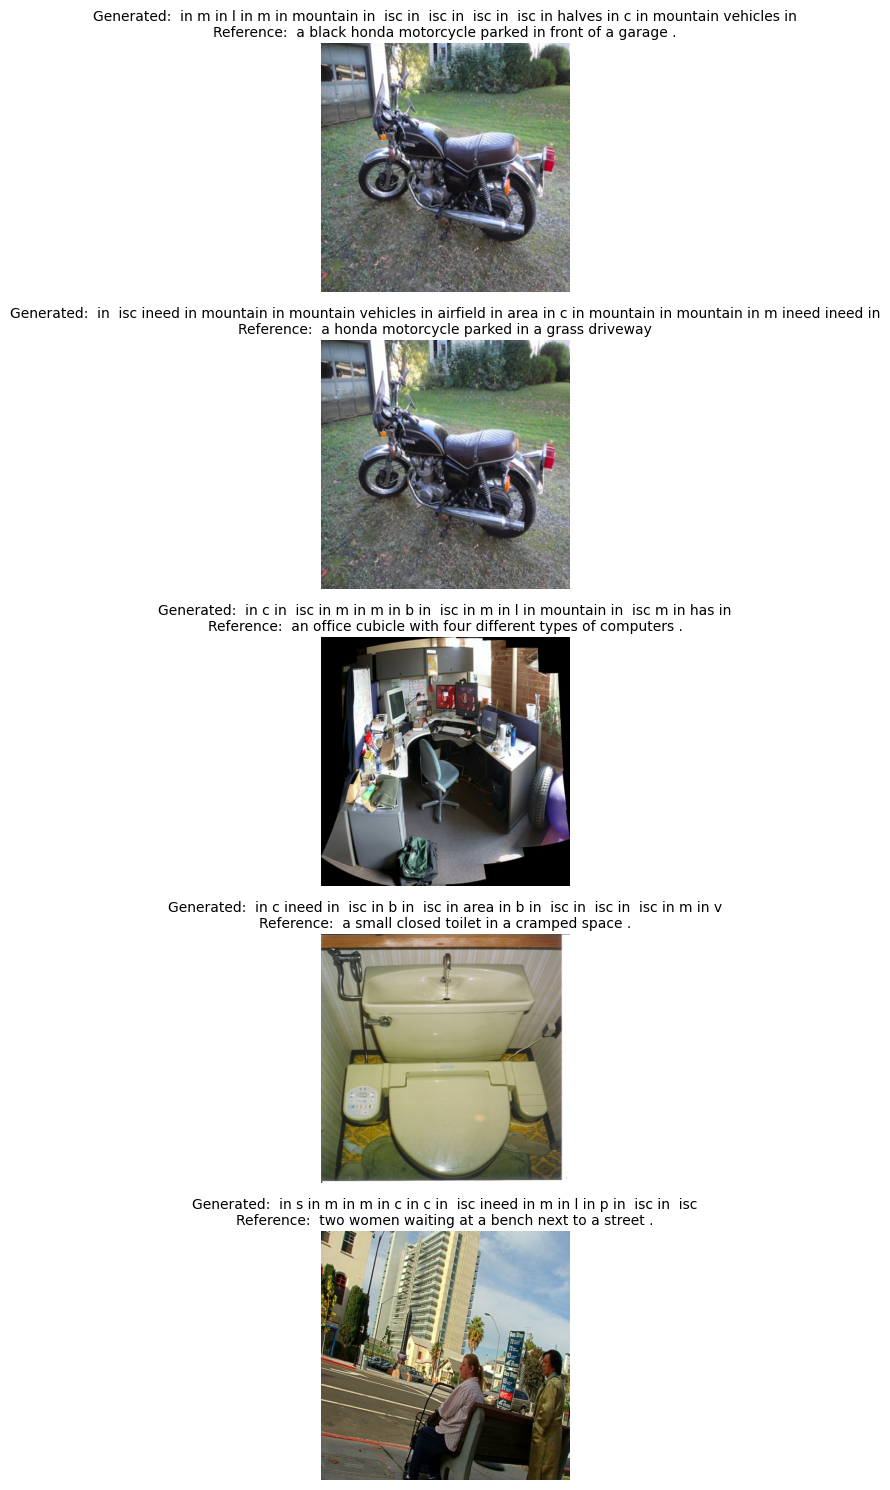

In [24]:
visualize_caption_samples(
    checkpoint_dir="/home/mahanthyalla/dev/image-captioning-ViT-GPT/src/checkpoints/vitgpt-base/vit-gpt-base/v7.8.ddp_train/training/checkpoints/checkpoint_step_3000",
    tokenizer=tokenizer,
    val_loader=val_loader,
    num_samples=5
)